[*] Lutfen data.csv dosyasini yukleyin...


Saving data.csv to data.csv
Epoch 1/100


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.4059 - loss: 1.2492 - val_accuracy: 0.3913 - val_loss: 1.2183 - learning_rate: 0.0010
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5129 - loss: 0.7798 - val_accuracy: 0.7246 - val_loss: 1.1230 - learning_rate: 0.0010
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5593 - loss: 0.6710 - val_accuracy: 0.7246 - val_loss: 1.0268 - learning_rate: 0.0010
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.5735 - loss: 0.6138 - val_accuracy: 0.7319 - val_loss: 0.9745 - learning_rate: 0.0010
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6211 - loss: 0.5428 - val_accuracy: 0.7536 - val_loss: 0.9224 - learning_rate: 0.0010
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6521 - loss: 0.4928 - val_accuracy: 0.7464 - val_loss: 0.8461 - learning_rate: 0.0010
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6443 - loss: 0.4527 - val_accuracy

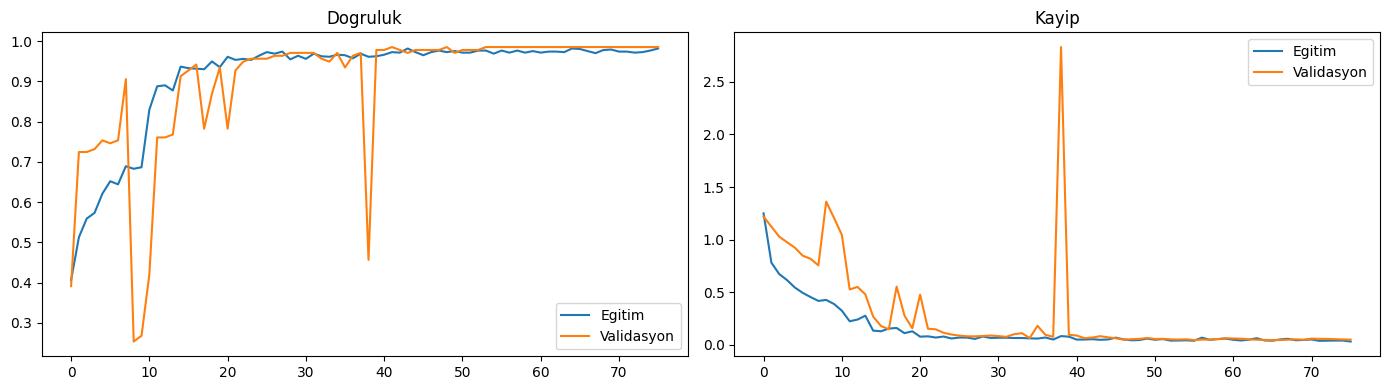

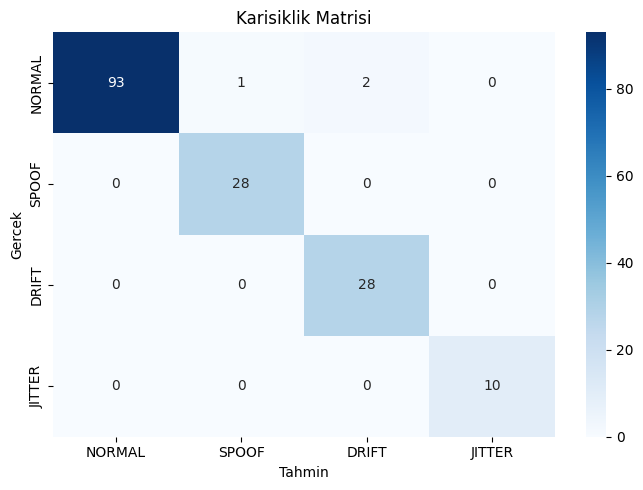

[+] model.h5 ve diger dosyalar indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


── Siniflandirma Raporu ──
              precision    recall  f1-score   support

      NORMAL       1.00      0.97      0.98        96
       SPOOF       0.97      1.00      0.98        28
       DRIFT       0.93      1.00      0.97        28
      JITTER       1.00      1.00      1.00        10

    accuracy                           0.98       162
   macro avg       0.97      0.99      0.98       162
weighted avg       0.98      0.98      0.98       162



In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import joblib
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from google.colab import files

print("[*] Lutfen data.csv dosyasini yukleyin...")
uploaded = files.upload()

df = pd.read_csv("data.csv")
df = df[df['label'].isin([0, 1, 2, 3])]

df.dropna(inplace=True)
df.sort_values(by="timestamp", inplace=True)
df.reset_index(drop=True, inplace=True)

CLASS_NAMES  = ["NORMAL", "SPOOF", "DRIFT", "JITTER"]
NUM_CLASSES  = len(CLASS_NAMES)
TIME_STEPS   = 30
NUM_FEATURES = 5

df["lat_diff"] = df["lat"].diff().fillna(0)
df["lon_diff"] = df["lon"].diff().fillna(0)

label_changes = df["label"].ne(df["label"].shift())
df.loc[label_changes, "lat_diff"] = 0
df.loc[label_changes, "lon_diff"] = 0

def compute_residual_std(series):
    x = np.arange(len(series))
    coef = np.polyfit(x, series, 1)
    residuals = series - np.polyval(coef, x)
    return residuals.std()

def build_windows(df, time_steps, label_col="label"):
    ham_cols = ["lat", "lon", "alt", "delta"]
    diff_cols = ["lat_diff", "lon_diff"]

    raw_ham  = df[ham_cols].values
    raw_diff = df[diff_cols].values
    labels   = df[label_col].values

    X, y = [], []

    for i in range(len(raw_ham) - time_steps + 1):
        window_ham  = raw_ham[i : i + time_steps]
        window_diff = raw_diff[i : i + time_steps]

        delta_col = window_ham[:, 3:4]
        lat_diffs = window_diff[:, 0:1]
        lon_diffs = window_diff[:, 1:2]

        lat_res_std = np.full((time_steps, 1), compute_residual_std(window_ham[:, 0]))
        lon_res_std = np.full((time_steps, 1), compute_residual_std(window_ham[:, 1]))

        window_full = np.concatenate([delta_col, lat_diffs, lon_diffs, lat_res_std, lon_res_std], axis=1)
        X.append(window_full)

        window_labels = labels[i : i + time_steps]
        unique, counts = np.unique(window_labels, return_counts=True)
        majority_label = unique[np.argmax(counts)]
        y.append(majority_label)

    return np.array(X), np.array(y)

X_raw, y = build_windows(df, TIME_STEPS)

n_samples = X_raw.shape[0]
X_flat    = X_raw.reshape(-1, NUM_FEATURES)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
X_scaled = X_scaled.reshape(n_samples, TIME_STEPS, NUM_FEATURES)

joblib.dump(scaler, "scaler.pkl")

y_cat = to_categorical(y, num_classes=NUM_CLASSES)

X_temp, X_test, y_temp, y_test = train_test_split(X_scaled, y_cat, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.15, random_state=42, stratify=np.argmax(y_temp, axis=1))

y_int = np.argmax(y_cat, axis=1)
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

model = Sequential([
    GRU(64, input_shape=(TIME_STEPS, NUM_FEATURES), return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    GRU(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3), loss="categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=100, batch_size=32, class_weight=class_weight_dict, callbacks=callbacks, verbose=1)

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = np.argmax(y_pred_prob, axis=1)
y_true      = np.argmax(y_test,      axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history.history["accuracy"],     label="Egitim")
axes[0].plot(history.history["val_accuracy"], label="Validasyon")
axes[0].set_title("Dogruluk")
axes[0].legend()

axes[1].plot(history.history["loss"],     label="Egitim")
axes[1].plot(history.history["val_loss"], label="Validasyon")
axes[1].set_title("Kayip")
axes[1].legend()

plt.tight_layout()
plt.savefig("egitim_grafigi.png", dpi=150)
plt.show()

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES
)
plt.title("Karisiklik Matrisi")
plt.ylabel("Gercek")
plt.xlabel("Tahmin")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

model.save("model.h5")
print("[+] model.h5 ve diger dosyalar indiriliyor...")

files.download("model.h5")
files.download("scaler.pkl")
files.download("egitim_grafigi.png")
files.download("confusion_matrix.png")
print("\n── Siniflandirma Raporu ──")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
